In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import geopandas as gpd
import os

In [3]:
growth_rates_emissions_energy_prod_income_level_country_df = pd.read_csv("../datasets/growth_rates_emissions_energy_prod_income_level_country_df.csv", index_col=None)

# growth_rates_emissions_energy_prod_income_level_country_df = pd.read_csv("/content/growth_rates_emissions_energy_prod_income_level_country_df.csv", index_col=None)

In [4]:
growth_rates_emissions_energy_prod_income_level_country_df.head()

,Unnamed: 0,Country Name,Country Code,Series Name,Series Code,1989_1989,1990_1990,1991_1991,1992_1992,1993_1993,...,2015_2015,2016_2016,2017_2017,2018_2018,2019_2019,2020_2020,2021_2021,2022_2022,2023_2023,Income Level
0,0,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,21.708333,21.708333,21.708333,21.708333,21.708333,...,27.6,28.8,30.3,31.4,32.6,33.8,34.9,36.1,36.1,Low income
1,1,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,8.479167,8.479167,8.479167,8.479167,8.479167,...,11.4,12.6,13.5,14.5,15.6,16.4,17.4,18.5,18.5,Low income
2,2,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,66.031250,66.031250,66.031250,66.031250,66.031250,...,79.5,80.5,81.6,82.6,83.2,83.8,84.5,85.0,85.0,Low income
3,3,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,58.266667,58.266667,58.266667,58.266667,58.266667,...,71.5,97.7,97.7,93.4,97.7,97.7,97.7,85.3,85.3,Low income
4,4,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,57.461905,57.461905,57.461905,57.461905,57.461905,...,64.6,97.1,97.1,91.6,97.1,97.1,97.1,81.7,81.7,Low income


In [5]:
growth_rates_emissions_energy_prod_income_level_country_df.shape

(10533, 41)

In [6]:
growth_rates_emissions_energy_prod_income_level_country_df.isnull().sum()

Unnamed: 0      0
Country Name    0
Country Code    0
Series Name     0
Series Code     0
1989_1989       0
1990_1990       0
1991_1991       0
1992_1992       0
1993_1993       0
1994_1994       0
1995_1995       0
1996_1996       0
1997_1997       0
1998_1998       0
1999_1999       0
2000_2000       0
2001_2001       0
2002_2002       0
2003_2003       0
2004_2004       0
2005_2005       0
2006_2006       0
2007_2007       0
2008_2008       0
2009_2009       0
2010_2010       0
2011_2011       0
2012_2012       0
2013_2013       0
2014_2014       0
2015_2015       0
2016_2016       0
2017_2017       0
2018_2018       0
2019_2019       0
2020_2020       0
2021_2021       0
2022_2022       0
2023_2023       0
Income Level    0
dtype: int64

In [7]:
series_names = growth_rates_emissions_energy_prod_income_level_country_df['Series Name'].unique()
print(series_names)

['Access to clean fuels and technologies for cooking (% of population)'
 'Access to clean fuels and technologies for cooking, rural (% of rural population)'
 'Access to clean fuels and technologies for cooking, urban (% of urban population)'
 'Access to electricity (% of population)'
 'Access to electricity, rural (% of rural population)'
 'Access to electricity, urban (% of urban population)'
 'Agriculture, forestry, and fishing, value added (annual % growth)'
 'Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)'
 'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)'
 'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)'
 'Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)'
 'Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)'
 'Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)'
 'Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)'
 'Carbon dioxide (CO2)

In [50]:
summary_stats = growth_rates_emissions_energy_prod_income_level_country_df.describe().transpose()

summary_stats['missing_values'] = growth_rates_emissions_energy_prod_income_level_country_df.isnull().sum()
summary_stats['data_type'] = growth_rates_emissions_energy_prod_income_level_country_df.dtypes

summary_stats

,count,mean,std,min,25%,50%,75%,max,missing_values,data_type
Unnamed: 0,10533.0,8.159103e+03,4.790349e+03,0.000000,3862.000000,8166.000000,12442.000000,1.648600e+04,0,int64
1989_1989,10533.0,1.802183e+06,8.128573e+07,-1021.666177,0.025600,2.761141,23.188833,5.709000e+09,0,float64
1990_1990,10533.0,1.926400e+06,8.726340e+07,-1138.375155,0.017200,2.694281,23.656900,5.897000e+09,0,float64
1991_1991,10533.0,2.085986e+06,9.786394e+07,-1205.963769,0.008600,2.078142,16.295880,6.931000e+09,0,float64
1992_1992,10533.0,2.334328e+06,1.082424e+08,-1116.357083,0.010000,2.249800,16.775000,7.917000e+09,0,float64
1993_1993,10533.0,2.326922e+06,1.100079e+08,-1162.653526,0.011100,2.341296,16.826594,8.221000e+09,0,float64
1994_1994,10533.0,2.529144e+06,1.144719e+08,-1411.426460,0.012400,2.389997,17.920536,7.939000e+09,0,float64
1995_1995,10533.0,2.937164e+06,1.222945e+08,-1373.825545,0.019800,2.726426,18.832460,8.479000e+09,0,float64
1996_1996,10533.0,3.017768e+06,1.217673e+08,-1377.285479,0.025100,2.761141,19.482430,7.452000e+09,0,float64
1997_1997,10533.0,3.258821e+06,1.289921e+08,-1617.774354,0.025700,2.822300,20.164627,7.383000e+09,0,float64


## Income Level Visualisation

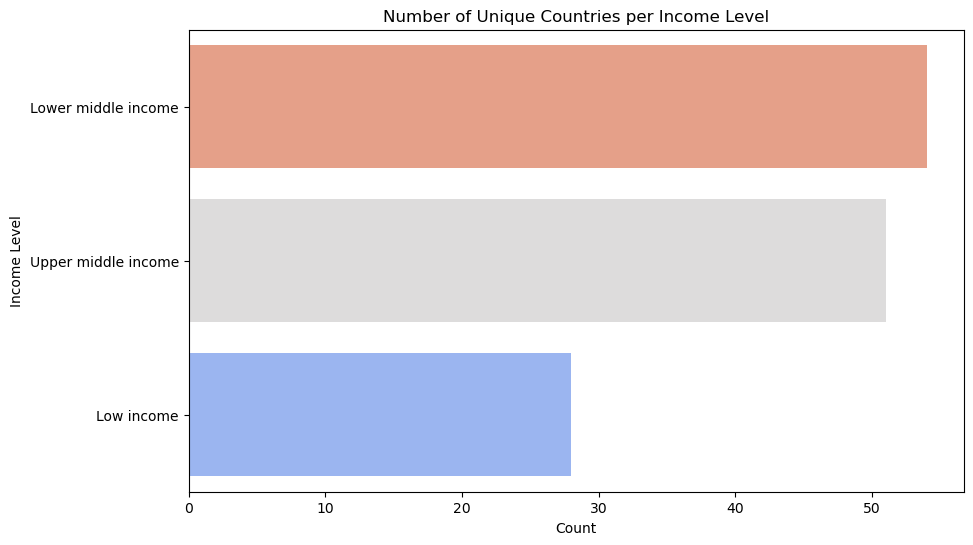

In [10]:
plt.figure(figsize=(10, 6))
unique_countries = growth_rates_emissions_energy_prod_income_level_country_df[["Country Name", "Income Level"]].drop_duplicates()

sns.countplot(y="Income Level", data=unique_countries, hue="Income Level", palette="coolwarm", legend=False,
              order=unique_countries["Income Level"].value_counts().index)
plt.title("Number of Unique Countries per Income Level")
plt.xlabel("Count")
plt.ylabel("Income Level")
plt.show()

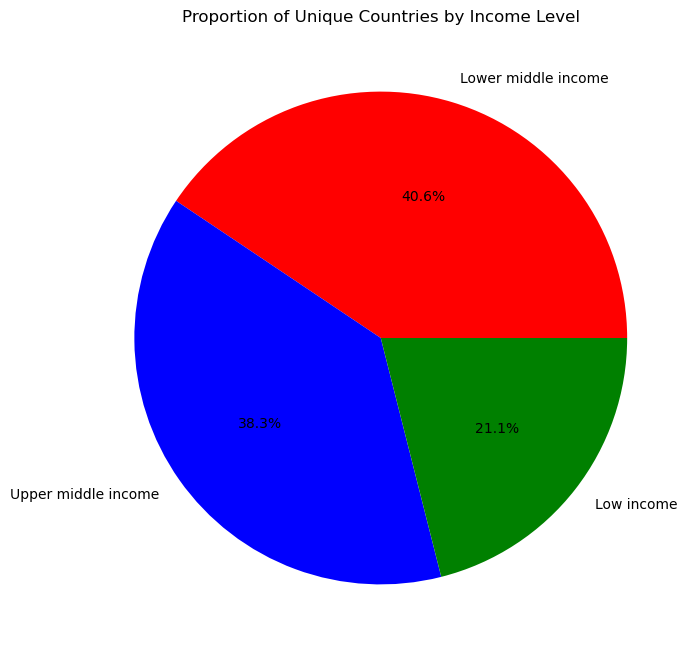

In [11]:
plt.figure(figsize=(8, 8))

unique_countries["Income Level"].value_counts().plot.pie(autopct="%1.1f%%", colors=["red", "blue", "green"])

plt.title("Proportion of Unique Countries by Income Level")
plt.ylabel("")
plt.show()


## Top Series Visualisations

In [13]:
# Number of unique series in the dataset
num_series = growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].nunique()
print(f"Total Unique Series: {num_series}")

# Count series occurrences
series_counts = growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].value_counts()

# Display the top series
print("Top 10 Most Frequent Series:\n", series_counts.head(10))

Total Unique Series: 91
Top 10 Most Frequent Series:
 Series Name
Renewable electricity output (% of total electricity output)                                       133
PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)                             132
GDP per capita growth (annual %)                                                                   132
Renewable energy consumption (% of total final energy consumption)                                 132
GDP growth (annual %)                                                                              132
Access to electricity (% of population)                                                            132
PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)       131
PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-1 value (% of total)    131
PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-2 value (% of total)    131
PM2.5 p

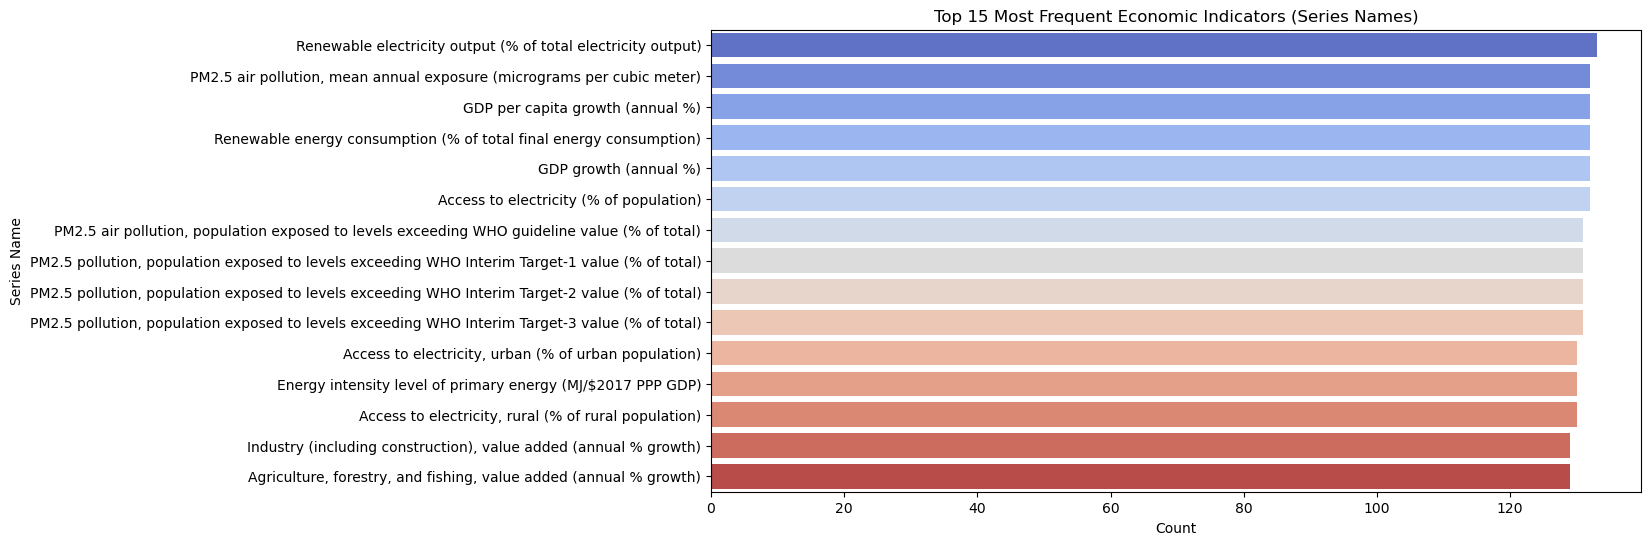

In [14]:
plt.figure(figsize=(12, 6))

# Convert series_counts into a DataFrame
series_df = series_counts.head(15).reset_index()
series_df.columns = ["Series Name", "Count"]

sns.barplot(y="Series Name", x="Count", hue="Series Name", data=series_df, palette="coolwarm", legend=False)

plt.title("Top 15 Most Frequent Economic Indicators (Series Names)")
plt.xlabel("Count")
plt.ylabel("Series Name")
plt.show()


## Groupby income level and list the countries

In [16]:
# Group by Income Level and list unique countries
income_groups = growth_rates_emissions_energy_prod_income_level_country_df.groupby("Income Level")["Country Name"].unique()

# Convert to dictionary for easy access
income_level_countries = {level: list(countries) for level, countries in income_groups.items()}

# Convert to DataFrame for better visualization
income_level_df = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in income_level_countries.items()]))
income_level_df.head()

,Low income,Lower middle income,Upper middle income
0,Afghanistan,Algeria,Albania
1,Burkina Faso,Angola,American Samoa
2,Burundi,Bangladesh,Argentina
3,Central African Republic,Benin,Armenia
4,Chad,Bhutan,Azerbaijan


--------------------------------------------------------------------------------------------------------------------------------------

### Correlation between different series
This will directly contribute to my research questions different parts, and correlate between renewable energy adoption, energy efficiency, sectoral economic growth, and variation of CO2 emissions levels.

1. Renewable Energy Adoption (from Energy Production & Use)
  - Renewable electricity output (% of total electricity output)

  - Electricity production from renewable sources, excluding hydroelectric (%)

  - Renewable energy consumption (% of total final energy consumption)

  - Combustible renewables and waste (% of total energy)

2. Energy Efficiency (from Energy Production & Use)
  - Energy intensity level of primary energy (MJ/$2017 PPP GDP)

  - GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent)

  - Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)

  - Fossil fuel energy consumption (% of total)

3. Sectoral Economic Growth (from Growth Rates)
  - Agriculture, forestry, and fishing, value added (annual % growth)

  - Industry (including construction), value added (annual % growth)

  - Manufacturing, value added (annual % growth)

  - Services, value added (annual % growth)

4. CO₂ Emissions & Environmental Impact (from Emissions)
  - Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)

  - CO₂ emissions per capita

  - CO₂ emissions from Power, Industry, Transport, and Agriculture

  - Total greenhouse gas emissions excluding LULUCF

  - Carbon intensity of GDP

#### Renewable Energy Adoption

In [21]:
renewable_series = [
    "Renewable electricity output (% of total electricity output)",
    "Electricity production from renewable sources, excluding hydroelectric (% of total)",
    "Renewable energy consumption (% of total final energy consumption)",
    "Combustible renewables and waste (% of total energy)"
]

#### Energy Efficiency

In [23]:
efficiency_series = [
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)",
    "GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent)",
    "Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)",
    "Fossil fuel energy consumption (% of total)"
]

#### Sectoral Economic Growth

In [25]:
growth_series = [
    "Agriculture, forestry, and fishing, value added (annual % growth)",
    "Industry (including construction), value added (annual % growth)",
    "Manufacturing, value added (annual % growth)",
    "Services, value added (annual % growth)"
]

#### Emissions

In [27]:
emission_series = [
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)",
    "Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP)",
    "Total greenhouse gas emissions excluding LULUCF (Mt CO2e)",
    "Total greenhouse gas emissions excluding LULUCF per capita (t CO2e/capita)"
]

In [28]:
all_research_series = renewable_series + efficiency_series + growth_series + emission_series

### Sector-Based Correlation (Pearson, Spearman, Kendall)

Agriculture sector correlation matrix | Low income | pearson
 Series Name                                         Agriculture, forestry, and fishing, value added (annual % growth)
Series Name                                                                                                          
Agriculture, forestry, and fishing, value added...                                           1.000000                
Carbon dioxide (CO2) emissions (total) excludin...                                          -0.195055                
Carbon dioxide (CO2) emissions excluding LULUCF...                                          -0.554879                
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                          -0.059670                
Combustible renewables and waste (% of total en...                                           0.345929                
Electricity production from renewable sources, ...                                           0.420277           

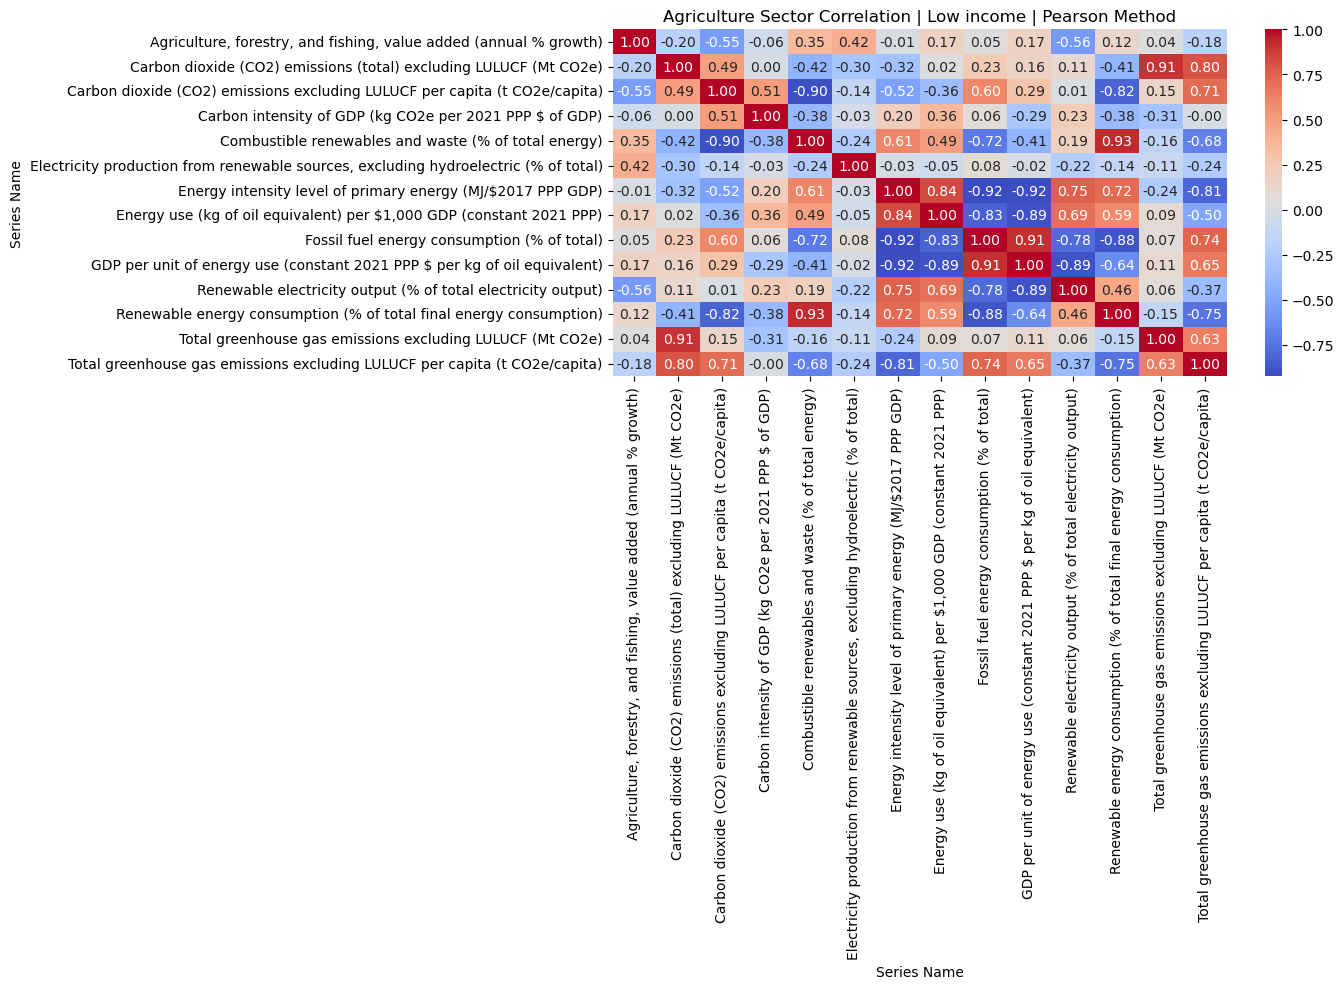

Industry sector correlation matrix | Low income | pearson
 Series Name                                         Industry (including construction), value added (annual % growth)  \
Series Name                                                                                                            
Carbon dioxide (CO2) emissions (total) excludin...                                           0.412771                  
Carbon dioxide (CO2) emissions excluding LULUCF...                                          -0.062254                  
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                           0.416084                  
Combustible renewables and waste (% of total en...                                           0.115439                  
Electricity production from renewable sources, ...                                           0.093156                  
Energy intensity level of primary energy (MJ/$2...                                           0.402970

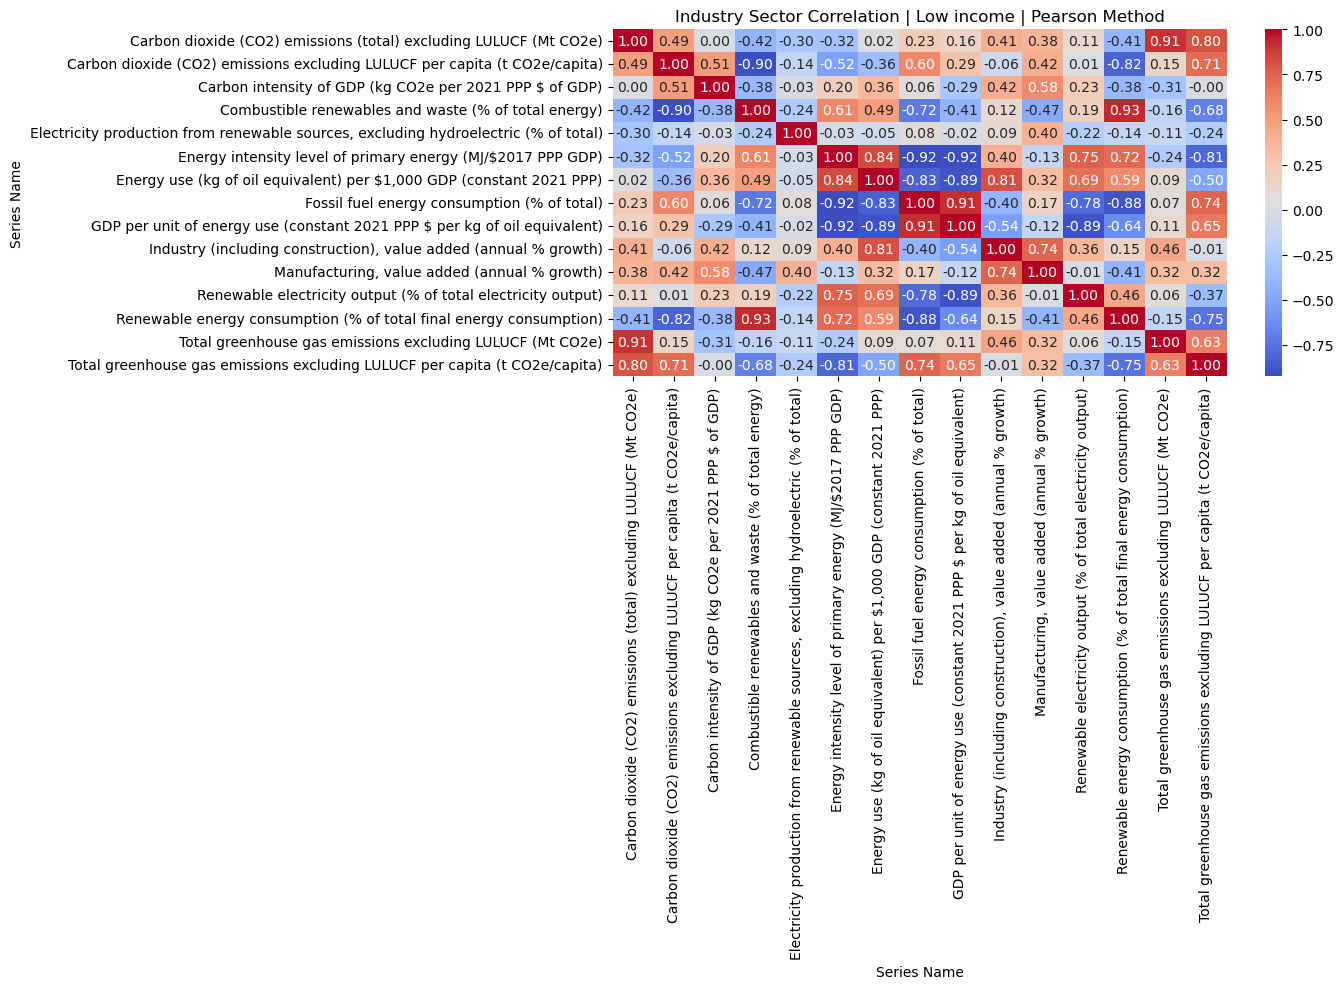

Services sector correlation matrix | Low income | pearson
 Series Name                                         Services, value added (annual % growth)
Series Name                                                                                
Carbon dioxide (CO2) emissions (total) excludin...                                -0.073658
Carbon dioxide (CO2) emissions excluding LULUCF...                                -0.266592
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                 0.281058
Combustible renewables and waste (% of total en...                                 0.333758
Electricity production from renewable sources, ...                                 0.255204
Energy intensity level of primary energy (MJ/$2...                                 0.526917
Energy use (kg of oil equivalent) per $1,000 GD...                                 0.816310
Fossil fuel energy consumption (% of total)                                       -0.628387
GDP per unit of energ

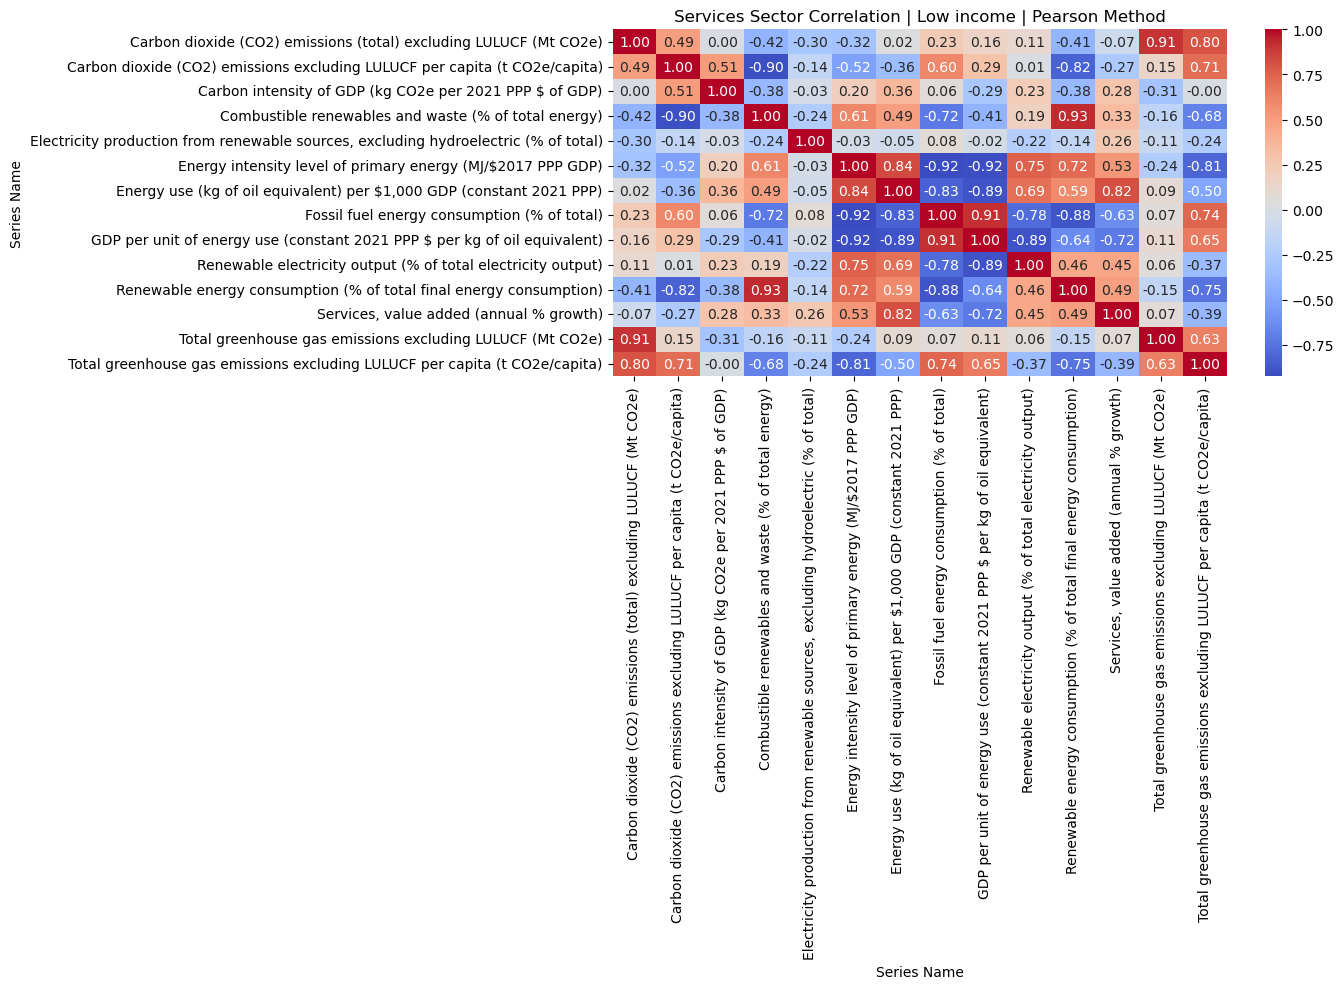

Agriculture sector correlation matrix | Lower middle income | pearson
 Series Name                                         Agriculture, forestry, and fishing, value added (annual % growth)
Series Name                                                                                                          
Agriculture, forestry, and fishing, value added...                                           1.000000                
Carbon dioxide (CO2) emissions (total) excludin...                                           0.001798                
Carbon dioxide (CO2) emissions excluding LULUCF...                                          -0.142500                
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                          -0.036364                
Combustible renewables and waste (% of total en...                                           0.104884                
Electricity production from renewable sources, ...                                          -0.286211  

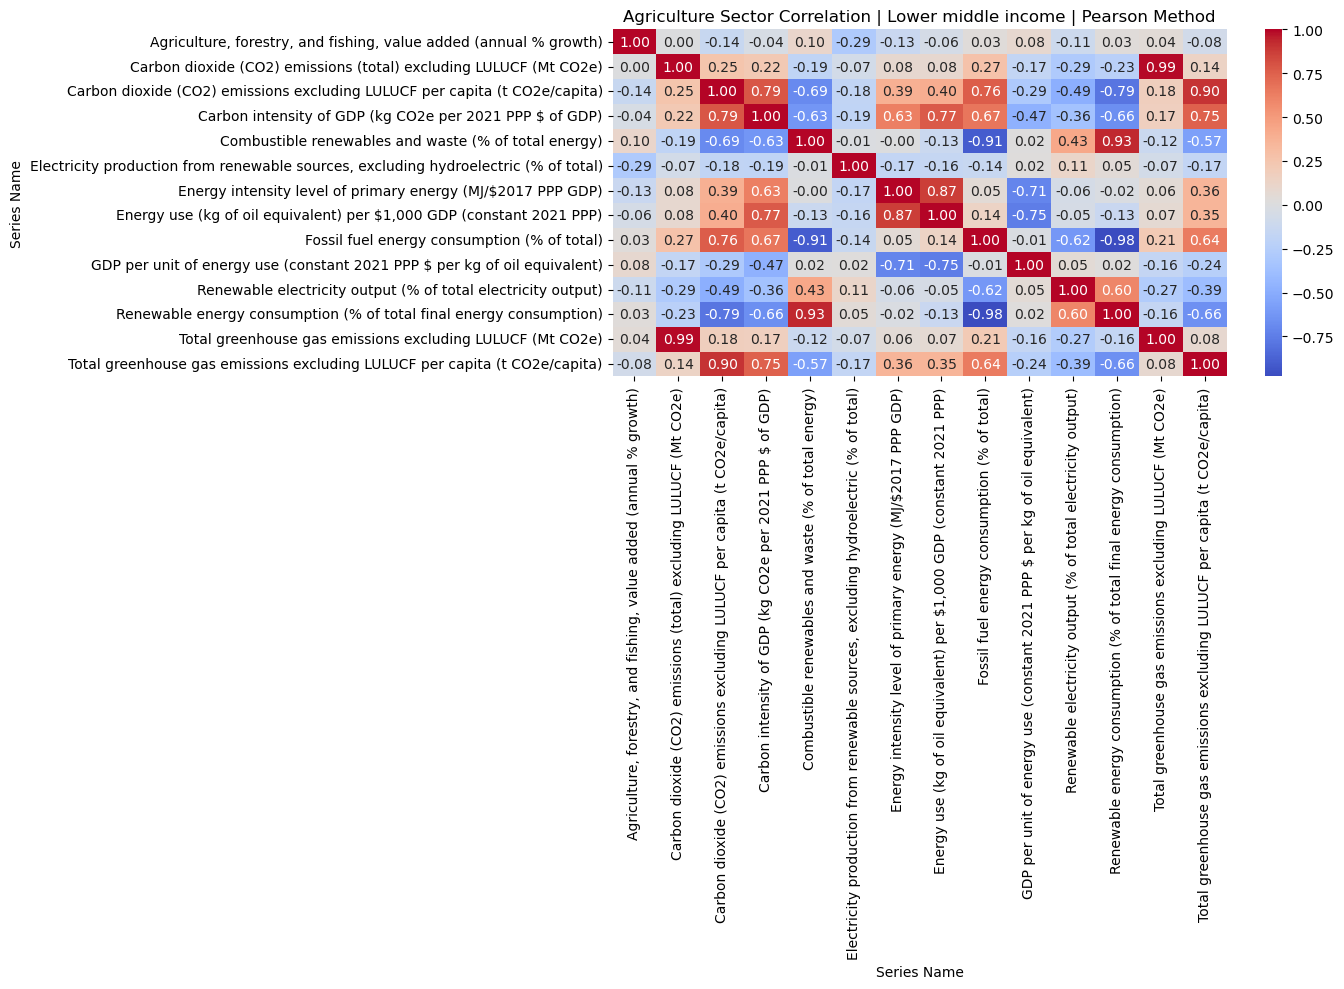

Industry sector correlation matrix | Lower middle income | pearson
 Series Name                                         Industry (including construction), value added (annual % growth)  \
Series Name                                                                                                            
Carbon dioxide (CO2) emissions (total) excludin...                                           0.010215                  
Carbon dioxide (CO2) emissions excluding LULUCF...                                          -0.459296                  
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                          -0.276354                  
Combustible renewables and waste (% of total en...                                           0.377847                  
Electricity production from renewable sources, ...                                          -0.050746                  
Energy intensity level of primary energy (MJ/$2...                                          

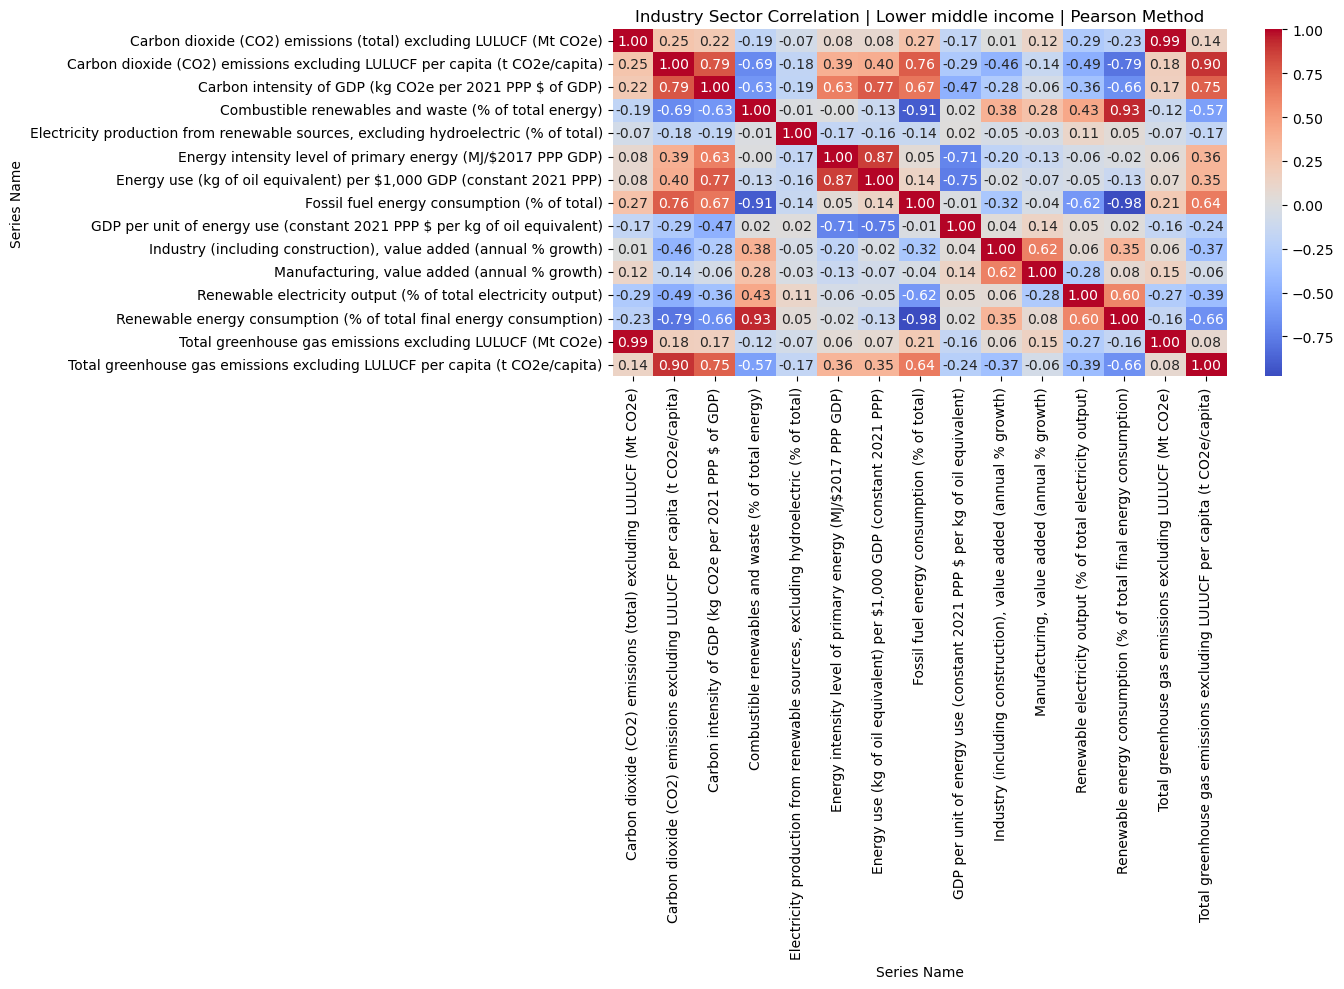

Services sector correlation matrix | Lower middle income | pearson
 Series Name                                         Services, value added (annual % growth)
Series Name                                                                                
Carbon dioxide (CO2) emissions (total) excludin...                                 0.214479
Carbon dioxide (CO2) emissions excluding LULUCF...                                -0.327552
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                -0.116532
Combustible renewables and waste (% of total en...                                 0.257093
Electricity production from renewable sources, ...                                -0.085792
Energy intensity level of primary energy (MJ/$2...                                -0.135347
Energy use (kg of oil equivalent) per $1,000 GD...                                -0.020871
Fossil fuel energy consumption (% of total)                                       -0.154450
GDP per unit

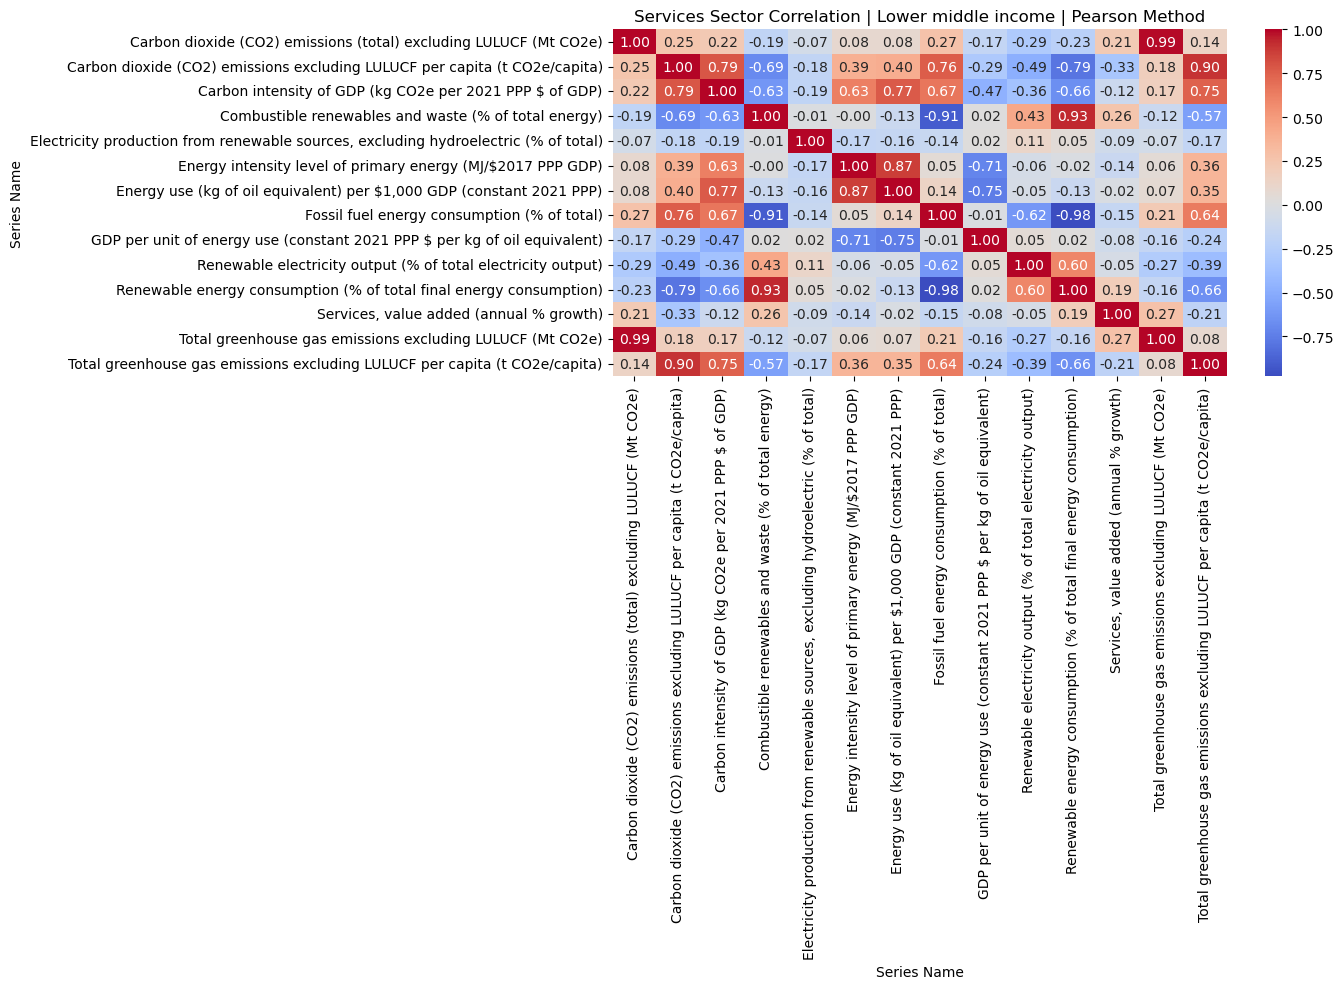

Agriculture sector correlation matrix | Upper middle income | pearson
 Series Name                                         Agriculture, forestry, and fishing, value added (annual % growth)
Series Name                                                                                                          
Agriculture, forestry, and fishing, value added...                                           1.000000                
Carbon dioxide (CO2) emissions (total) excludin...                                           0.278703                
Carbon dioxide (CO2) emissions excluding LULUCF...                                          -0.306709                
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                          -0.098721                
Combustible renewables and waste (% of total en...                                           0.337423                
Electricity production from renewable sources, ...                                           0.058649  

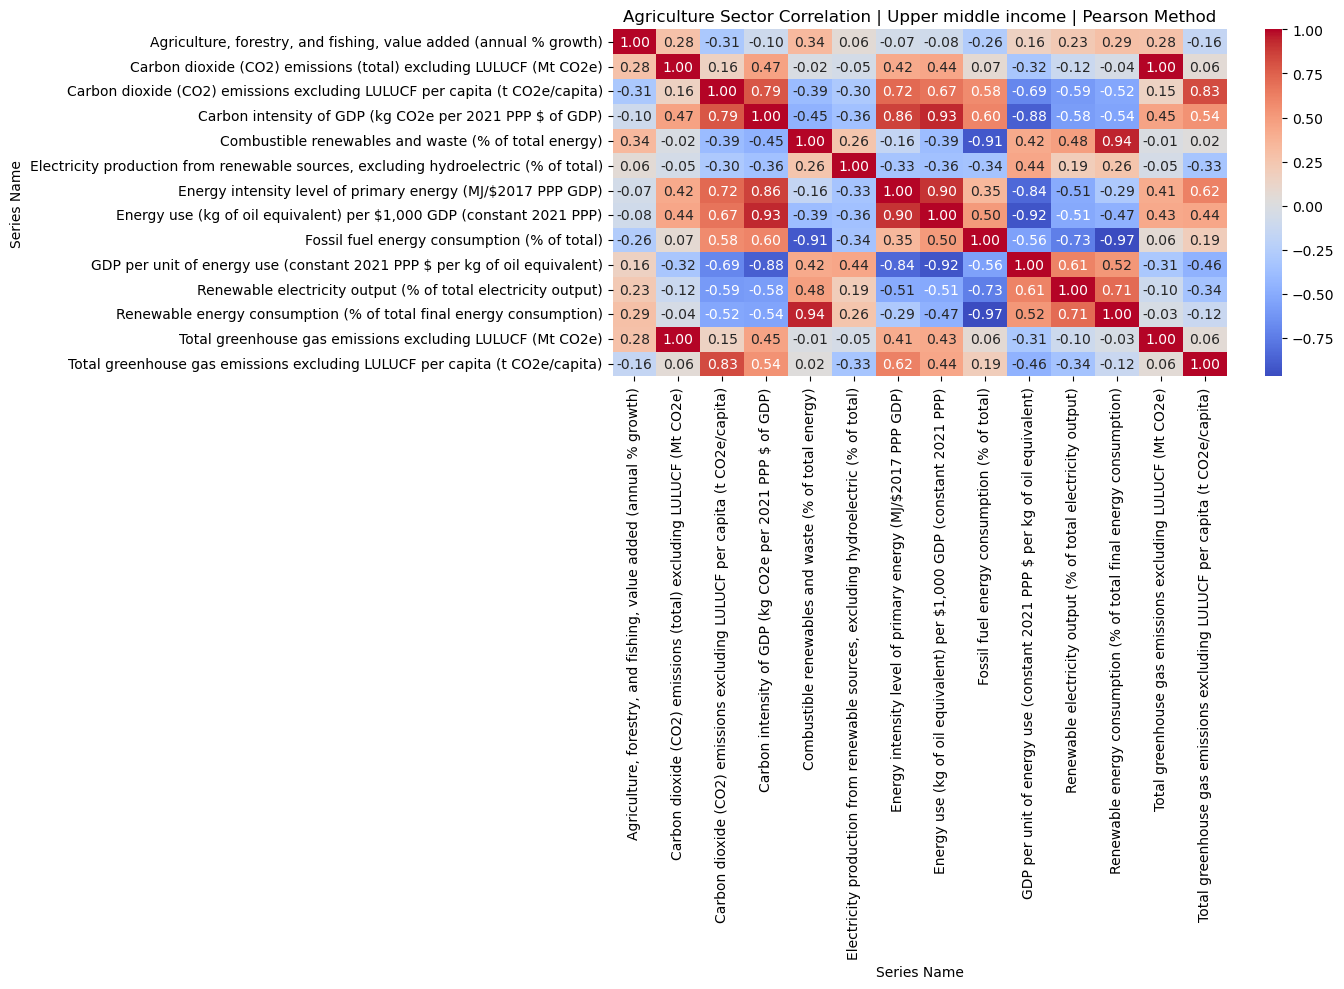

Industry sector correlation matrix | Upper middle income | pearson
 Series Name                                         Industry (including construction), value added (annual % growth)  \
Series Name                                                                                                            
Carbon dioxide (CO2) emissions (total) excludin...                                          -0.117543                  
Carbon dioxide (CO2) emissions excluding LULUCF...                                          -0.067876                  
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                           0.068456                  
Combustible renewables and waste (% of total en...                                          -0.186541                  
Electricity production from renewable sources, ...                                          -0.014840                  
Energy intensity level of primary energy (MJ/$2...                                          

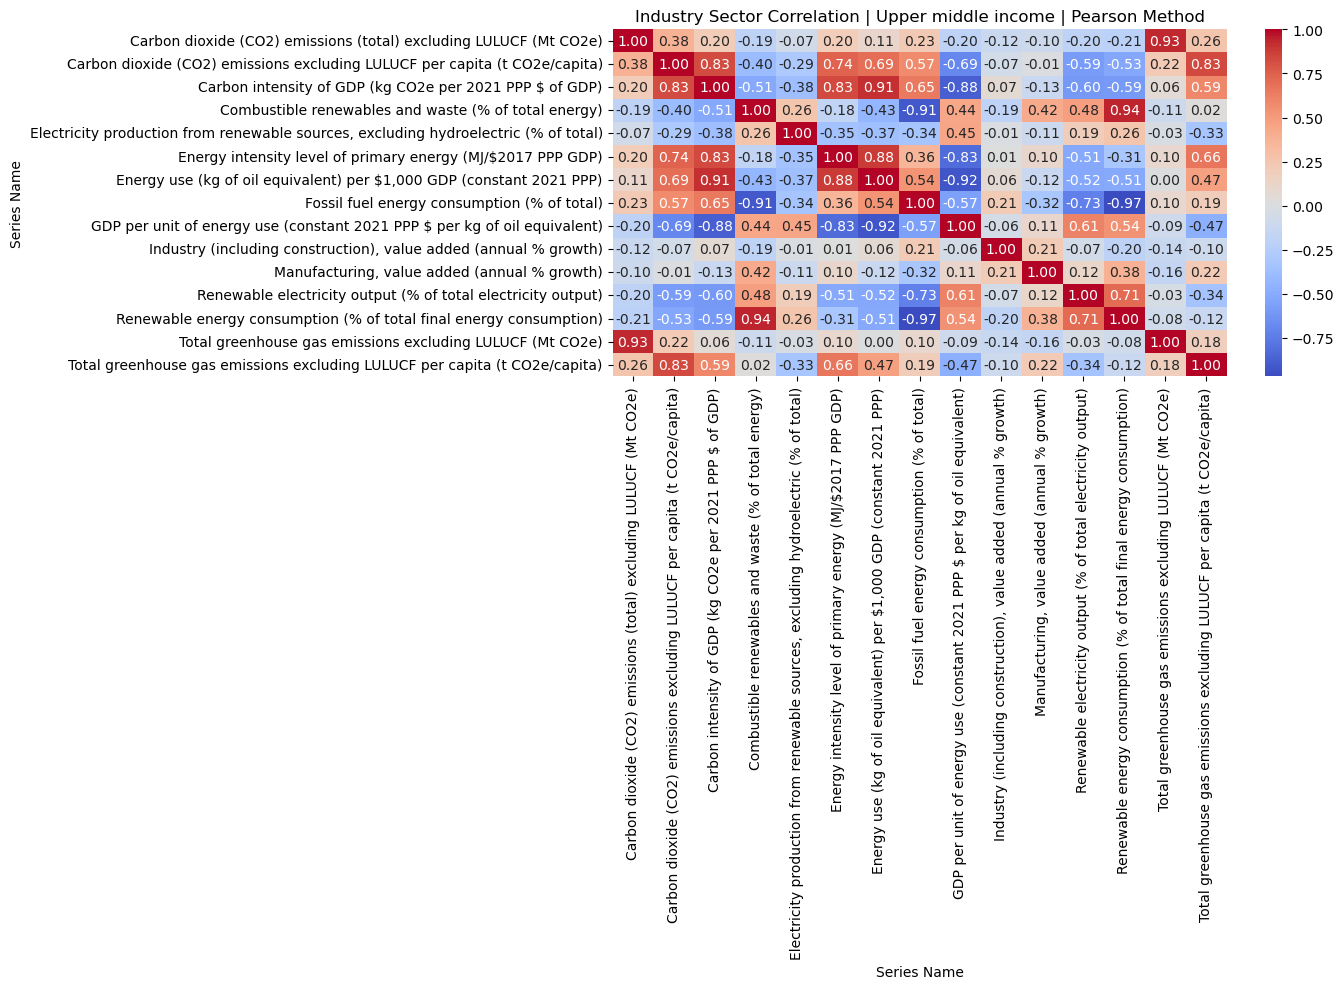

Services sector correlation matrix | Upper middle income | pearson
 Series Name                                         Services, value added (annual % growth)
Series Name                                                                                
Carbon dioxide (CO2) emissions (total) excludin...                                 0.418488
Carbon dioxide (CO2) emissions excluding LULUCF...                                -0.133638
Carbon intensity of GDP (kg CO2e per 2021 PPP $...                                 0.052963
Combustible renewables and waste (% of total en...                                 0.005388
Electricity production from renewable sources, ...                                 0.052040
Energy intensity level of primary energy (MJ/$2...                                 0.068677
Energy use (kg of oil equivalent) per $1,000 GD...                                 0.162462
Fossil fuel energy consumption (% of total)                                       -0.046473
GDP per unit

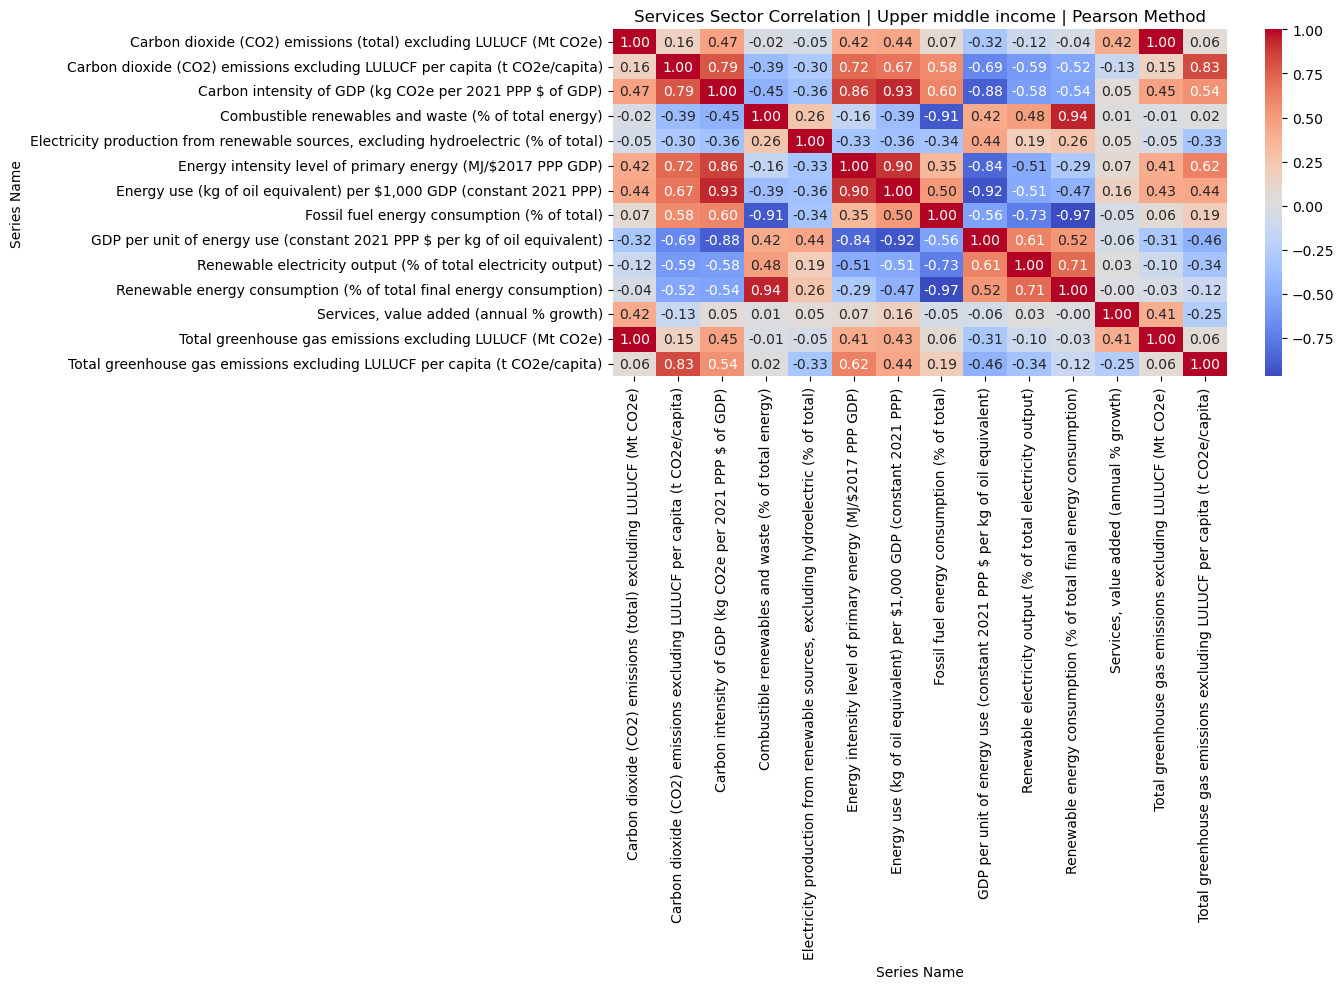

In [30]:
#6
year_columns = [col for col in growth_rates_emissions_energy_prod_income_level_country_df.columns if col.startswith("19") or col.startswith("20")]

income_levels = ["Low income", "Lower middle income", "Upper middle income"]

sector_series_dict = {
    "Agriculture": ["Agriculture, forestry, and fishing, value added (annual % growth)"],
    "Industry": [
        "Industry (including construction), value added (annual % growth)",
        "Manufacturing, value added (annual % growth)"
    ],
    "Services": ["Services, value added (annual % growth)"]
}

for income in income_levels:
    for sector, sector_growth_series in sector_series_dict.items():
        sector_related_series = renewable_series + efficiency_series + emission_series + sector_growth_series

        filtered_df = growth_rates_emissions_energy_prod_income_level_country_df[
            (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income) &
            (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].isin(sector_related_series))
        ].copy()

        filtered_df["Series Avg"] = filtered_df[year_columns].mean(axis=1)

        pivot_df = filtered_df.pivot_table(
            index="Country Name", columns="Series Name", values="Series Avg"
        ).dropna()

        if pivot_df.shape[0] < 3:
            print(f"Skipped {sector} - {income} (not enough data)")
            continue

        for method in ['pearson']: # for method in ['pearson', 'spearman', 'kendall']:
            corr_matrix = pivot_df.corr(method=method)
            print(f"{sector} sector correlation matrix | {income} | {method}\n", corr_matrix[sector_growth_series])

            plt.figure(figsize=(14, 10))
            sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
            plt.title(f"{sector} Sector Correlation | {income} | {method.title()} Method")
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()